# Hands-On 3 (optional) — Railway Logistics *Agentic Mesh*

> ▶️ **Open in Google Colab (one tap):** https://colab.research.google.com/github/thakkarkhyati/IIMK_Tutorials/blob/main/AI_Logistics_Railways_3hr/03c_HandsOn_Agentic_Mesh.ipynb  — then *Runtime → Run all*.
### A tiny, offline LLM-shaped orchestrator over deterministic railway engines

**Companion to:** `Optional_LLM_Agentic_Module.md`

This notebook builds a **miniature version of the Agentic Mesh** — the same architecture Khyati is
designing for HERE (`llm_architecture.png`), translated to Indian Railways.

**The one principle (write it on your hand):**
> The language model **orchestrates and explains**. The **deterministic engines do the maths.**

What we build, in order:
1. **Deterministic tools** — a routing engine and a rake-allocation engine (the Session-2 maths).
2. A **tool registry** — the 'menu' an LLM would be given.
3. An **orchestrator** — a stand-in Supervisor that reads a plain-English-style request, decides which
   tools to call in what order, runs them, and writes an **action plan with reasons**.
4. An **architecture diagram** and the **Monsoon Washout** scenario, end-to-end.
5. The **five commented lines** that swap our stand-in for a *real* LLM (OpenAI function-calling).

Runs **fully offline — no API key, no internet.**

> 🤖 *Why let the LLM only talk and never do the maths? Because a language model asked to divide 260 by 40
> will answer with great confidence and occasional creativity. We keep the arithmetic with the engines
> that are boringly, reliably correct — and let the LLM do what it's genuinely good at: explaining the plan.*


In [1]:
import importlib, subprocess, sys

def _ensure(pkg, pip_name=None):
    """Import pkg; pip-install quietly if missing. Fully offline otherwise."""
    try:
        return importlib.import_module(pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pip_name or pkg])
        return importlib.import_module(pkg)

np = _ensure("numpy")
pd = _ensure("pandas")
nx = _ensure("networkx")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import textwrap

np.random.seed(7)
pd.set_option('display.width', 120)

# Same palette as Sessions 1 & 2 and the slide deck.
THEME = {"navy": "#122136", "teal": "#00A8A0", "tealD": "#007A74",
         "amber": "#E88A00", "grey": "#9AA5B1", "ink": "#1E2A38"}

print('Environment ready — fully offline, no API key needed. (Yes, really. No cloud, no bill.) 🔌')


Environment ready — fully offline, no API key needed. (Yes, really. No cloud, no bill.) 🔌


## 1 · The railway network (the map underneath everything)

A small, illustrative corridor: nodes are stations/junctions/terminals, edges are track sections with a
**distance (km)** and a **base speed (km/h)**. This is the same kind of graph from Session 2 — a *digital
twin* the engines reason over.


In [2]:
# --- Build the network: node -> (x, y) for drawing ---
positions = {
    'JNPT':       (0.0, 2.0),
    'Kalyan':     (2.0, 3.0),
    'Karjat':     (2.0, 1.0),
    'Lonavala':   (4.0, 0.6),   # top of the Bhor Ghat climb
    'Ahmadnagar': (4.0, 2.2),
    'Daund':      (6.0, 3.0),
    'Pune':       (8.0, 2.5),
    'Solapur':    (8.0, 1.0),
}

# edges: (u, v, distance_km, base_speed_kmph)
edges = [
    ('JNPT',      'Kalyan',     70, 55),
    ('JNPT',      'Karjat',     100, 50),
    ('Kalyan',    'Karjat',      45, 50),
    # --- The Bhor Ghat line: short but STEEP and slow (Karjat -> Lonavala -> Pune) ---
    ('Karjat',    'Lonavala',    28, 30),   # the ghat climb: slide-prone, slow
    ('Lonavala',  'Pune',        65, 55),
    # --- Inland alternate: longer, flatter (Karjat -> Ahmadnagar -> Daund -> Pune) ---
    ('Karjat',    'Ahmadnagar', 150, 55),
    ('Ahmadnagar','Daund',      120, 60),
    ('Daund',     'Pune',        75, 65),
    ('Daund',     'Solapur',    130, 55),
    ('Ahmadnagar','Solapur',    240, 50),
]

def build_graph(edges):
    G = nx.Graph()
    for u, v, dist, spd in edges:
        # time in hours = distance / speed ; store both
        G.add_edge(u, v, distance=dist, speed=spd, time=round(dist / spd, 2))
    return G

G = build_graph(edges)
print(f'Network: {G.number_of_nodes()} nodes, {G.number_of_edges()} sections')


Network: 8 nodes, 10 sections


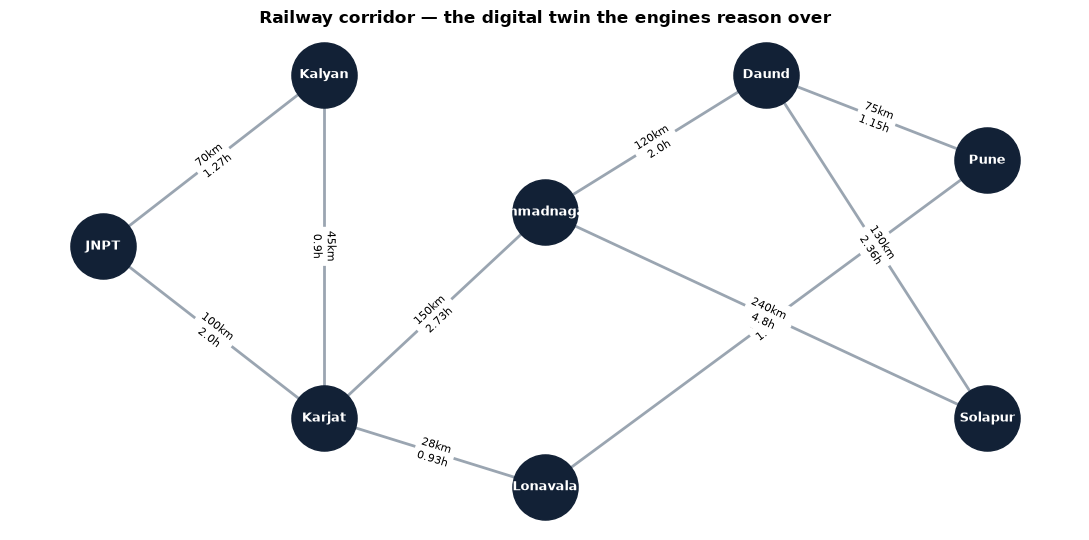

In [3]:
# Draw the network
fig, ax = plt.subplots(figsize=(11, 5.5))
nx.draw_networkx_edges(G, positions, ax=ax, width=2, edge_color=THEME['grey'])
nx.draw_networkx_nodes(G, positions, ax=ax, node_size=2200, node_color=THEME['navy'])
nx.draw_networkx_labels(G, positions, ax=ax, font_color='white', font_size=9, font_weight='bold')
edge_labels = {(u, v): f"{d['distance']}km\n{d['time']}h" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, positions, edge_labels=edge_labels, ax=ax, font_size=8)
ax.set_title('Railway corridor — the digital twin the engines reason over', fontsize=12, fontweight='bold')
ax.axis('off'); plt.tight_layout(); plt.show()


## 2 · The **deterministic tools** (the engines that do the maths)

These are plain, reliable Python functions — *no AI inside*. Same-inputs → same-outputs, every time.
This is the layer that must **never** be left to an LLM to guess.

- `best_route()` — fastest path via Dijkstra (weighted by travel **time**), returns path + hours + km.
- `predict_transit_time()` — a small deterministic model: time from route + a load/handling penalty.
- `allocate_rakes()` — a **scorecard** engine that assigns scarce rakes to the most valuable orders.


In [4]:
def best_route(G, src, dst, blocked_sections=None):
    """Fastest route by travel time. blocked_sections: list of (u, v) tuples to remove."""
    H = G.copy()
    if blocked_sections:
        for u, v in blocked_sections:
            if H.has_edge(u, v):
                H.remove_edge(u, v)
    if src not in H or dst not in H or not nx.has_path(H, src, dst):
        return {'path': None, 'hours': None, 'km': None, 'feasible': False}
    path = nx.shortest_path(H, src, dst, weight='time')
    hours = round(sum(H[path[i]][path[i+1]]['time'] for i in range(len(path)-1)), 2)
    km = int(sum(H[path[i]][path[i+1]]['distance'] for i in range(len(path)-1)))
    return {'path': path, 'hours': hours, 'km': km, 'feasible': True}


def predict_transit_time(G, src, dst, load_tonnes=3000, blocked_sections=None):
    """Deterministic transit-time estimate: base route time + handling penalty for heavier loads."""
    r = best_route(G, src, dst, blocked_sections)
    if not r['feasible']:
        return {'hours': None, 'feasible': False, 'route': None}
    handling_penalty = round(0.4 + 0.0003 * load_tonnes, 2)   # heavier rake => more dwell/handling
    total = round(r['hours'] + handling_penalty, 2)
    return {'hours': total, 'feasible': True, 'route': r['path'], 'km': r['km'],
            'handling_penalty_h': handling_penalty}


def allocate_rakes(spare_rakes, orders, G, blocked_sections=None):
    """Scorecard/greedy allocation: assign each scarce spare rake to the highest-value feasible order.
    Score = order_value - delay_cost, where delay_cost grows with transit hours."""
    COST_PER_HR = 90000  # Rs per hour of transit (opportunity + demurrage proxy)
    remaining = list(spare_rakes)          # e.g. ['S1','S2','S3'] each parked at a location
    order_rows = []
    assignments = []

    # Build a scored table of (rake, order) candidate pairs
    candidates = []
    for r_id, r_loc in spare_rakes.items():
        for o in orders:
            est = predict_transit_time(G, r_loc, o['dst'], o['tonnes'], blocked_sections)
            if not est['feasible']:
                continue
            delay_cost = est['hours'] * COST_PER_HR
            score = o['value'] - delay_cost
            candidates.append({'rake': r_id, 'rake_at': r_loc, 'order': o['id'], 'dst': o['dst'],
                               'value': o['value'], 'hours': est['hours'],
                               'delay_cost': int(delay_cost), 'score': int(score),
                               'route': est['route']})
    cand_df = pd.DataFrame(candidates).sort_values('score', ascending=False).reset_index(drop=True)

    used_rakes, used_orders = set(), set()
    for _, row in cand_df.iterrows():
        if row['rake'] in used_rakes or row['order'] in used_orders:
            continue
        used_rakes.add(row['rake']); used_orders.add(row['order'])
        assignments.append(row.to_dict())

    served_value = sum(a['value'] for a in assignments)
    unserved = [o['id'] for o in orders if o['id'] not in used_orders]
    return {'assignments': assignments, 'served_value': served_value,
            'unserved_orders': unserved, 'scorecard': cand_df}

print('Deterministic engines defined: best_route, predict_transit_time, allocate_rakes')


Deterministic engines defined: best_route, predict_transit_time, allocate_rakes


In [5]:
# Quick sanity checks on the engines
print('Fastest JNPT -> Pune:', best_route(G, 'JNPT', 'Pune'))
print('With Bhor Ghat (Karjat<->Lonavala) blocked:',
      best_route(G, 'JNPT', 'Pune', blocked_sections=[('Karjat', 'Lonavala')]))
print('Transit estimate (3500 t):', predict_transit_time(G, 'JNPT', 'Pune', 3500))


Fastest JNPT -> Pune: {'path': ['JNPT', 'Karjat', 'Lonavala', 'Pune'], 'hours': 4.11, 'km': 193, 'feasible': True}
With Bhor Ghat (Karjat<->Lonavala) blocked: {'path': ['JNPT', 'Karjat', 'Ahmadnagar', 'Daund', 'Pune'], 'hours': 7.88, 'km': 445, 'feasible': True}
Transit estimate (3500 t): {'hours': 5.56, 'feasible': True, 'route': ['JNPT', 'Karjat', 'Lonavala', 'Pune'], 'km': 193, 'handling_penalty_h': 1.45}


## 3 · The **tool registry** — the 'menu' an LLM is handed

When you wire a real LLM, you describe each tool (name, what it does, its inputs) and let the model
*choose* which to call. Here we make the same registry explicitly, so the mapping to real
function-calling is one-to-one.


In [6]:
TOOL_REGISTRY = {
    'best_route': {
        'fn': best_route,
        'desc': 'Fastest route between two stations by travel time; supports blocked sections.',
        'args': ['src', 'dst', 'blocked_sections'],
    },
    'predict_transit_time': {
        'fn': predict_transit_time,
        'desc': 'Deterministic transit-time estimate for a loaded rake between two stations.',
        'args': ['src', 'dst', 'load_tonnes', 'blocked_sections'],
    },
    'allocate_rakes': {
        'fn': allocate_rakes,
        'desc': 'Assign scarce spare rakes to the most valuable feasible orders (scorecard).',
        'args': ['spare_rakes', 'orders', 'blocked_sections'],
    },
}
for name, spec in TOOL_REGISTRY.items():
    print(f"- {name}({', '.join(spec['args'])}) -> {spec['desc']}")


- best_route(src, dst, blocked_sections) -> Fastest route between two stations by travel time; supports blocked sections.
- predict_transit_time(src, dst, load_tonnes, blocked_sections) -> Deterministic transit-time estimate for a loaded rake between two stations.
- allocate_rakes(spare_rakes, orders, blocked_sections) -> Assign scarce spare rakes to the most valuable feasible orders (scorecard).


## 4 · The **orchestrator** (our stand-in Supervisor agent)

A real Supervisor uses an LLM to read the request and decide the plan. To keep this **offline and
free**, we use a tiny rule-based parser that mimics that decision — detecting intents like *"a section
is blocked"*, *"re-route my rakes"*, *"assign spare rakes"*, *"draft a customer note"*. The moment you
plug in a real LLM, this function is the only thing you replace (see the last cell).

Notice: the orchestrator **never computes a route or an allocation itself** — it only *calls the
engines* and *assembles language*. That is the whole safety idea.


In [7]:
def parse_intents(query: str):
    """Stand-in for an LLM: detect which sub-tasks the request implies."""
    q = query.lower()
    intents = []
    if 'block' in q or 'washout' in q or 'down' in q or 'closed' in q:
        intents.append('handle_block')
    if 'route' in q or 're-route' in q or 'reroute' in q or 're-plan' in q or 'replan' in q:
        intents.append('reroute')
    if 'assign' in q or 'allocat' in q or 'spare' in q:
        intents.append('allocate')
    if 'note' in q or 'draft' in q or 'customer' in q or 'communicat' in q:
        intents.append('comms')
    return intents


def comms_draft(unserved_orders, orders_by_id):
    """Comms agent: draft a plain, courteous customer note for deprioritised orders."""
    if not unserved_orders:
        return 'No customer deprioritisation required — all priority orders were served.'
    lines = ['Dear Customer,',
             '',
             'Due to an unplanned section outage on our network, the following consignment(s) will '
             'be rescheduled to the next available rake to protect safety and overall reliability:']
    for oid in unserved_orders:
        o = orders_by_id[oid]
        lines.append(f"  - Order {oid} to {o['dst']} ({o['tonnes']} t): revised plan to follow shortly.")
    lines += ['', 'We regret the inconvenience and will confirm updated timings within the hour.',
              'Regards, Divisional Freight Control']
    return '\n'.join(lines)


def orchestrator(query, world):
    """The Supervisor: read request -> plan -> call engines -> synthesise an action plan."""
    G = world['G']
    blocked = world.get('blocked_sections')
    en_route_rakes = world['en_route_rakes']      # rakes already moving that may need re-routing
    spare_rakes = world['spare_rakes']            # scarce spares to assign
    orders = world['orders']
    orders_by_id = {o['id']: o for o in orders}

    intents = parse_intents(query)
    transcript = []          # audit trail: every agent action
    plan_sections = []

    # --- Condition/Weather agent (confirms the disruption) ---
    if 'handle_block' in intents and blocked:
        for (u, v) in blocked:
            transcript.append(('Condition-Agent', f'Confirmed outage on section {u} <-> {v}.'))
        plan_sections.append(f"**Disruption:** section(s) {', '.join(f'{u}-{v}' for u,v in blocked)} "
                             f"unavailable; re-planning around them.")

    # --- Routing agent (re-routes each affected rake) ---
    if 'reroute' in intents:
        reroute_rows = []
        for r in en_route_rakes:
            base = best_route(G, r['at'], r['dst'])                          # what it would have done
            new = best_route(G, r['at'], r['dst'], blocked_sections=blocked) # avoiding the outage
            transcript.append(('Routing-Agent',
                f"Rake {r['id']} {r['at']}->{r['dst']}: called best_route (blocked-aware)."))
            if not new['feasible']:
                reroute_rows.append({'rake': r['id'], 'to': r['dst'], 'status': 'NO PATH', 'hours': None,
                                     'route': None})
            else:
                delta = None if not base['feasible'] else round(new['hours'] - base['hours'], 2)
                reroute_rows.append({'rake': r['id'], 'to': r['dst'], 'status': 'rerouted',
                                     'hours': new['hours'], 'extra_h': delta,
                                     'route': ' -> '.join(new['path'])})
        world['_reroute'] = pd.DataFrame(reroute_rows)
        plan_sections.append('**Re-routing (12 rakes):** see table below; each computed by the routing '
                             'engine avoiding the outage.')

    # --- Allocation agent (assigns spare rakes to best orders) ---
    if 'allocate' in intents:
        alloc = allocate_rakes(spare_rakes, orders, G, blocked_sections=blocked)
        world['_alloc'] = alloc
        transcript.append(('Allocation-Agent',
            f'Called allocate_rakes for {len(spare_rakes)} spares over {len(orders)} orders.'))
        served = ', '.join(f"{a['rake']}->{a['order']} ({a['dst']}, {a['hours']}h)"
                           for a in alloc['assignments'])
        plan_sections.append(f"**Spare-rake allocation:** {served}. "
                             f"Priority value served: Rs {alloc['served_value']:,}. "
                             f"Deprioritised: {alloc['unserved_orders'] or 'none'}.")

    # --- Comms agent (drafts customer note) ---
    if 'comms' in intents:
        unserved = world.get('_alloc', {}).get('unserved_orders', [])
        note = comms_draft(unserved, orders_by_id)
        world['_comms'] = note
        transcript.append(('Comms-Agent', 'Drafted customer note for deprioritised order(s).'))
        plan_sections.append('**Customer note:** drafted (see below) — for officer approval before send.')

    world['_transcript'] = transcript
    world['_intents'] = intents
    world['_plan_sections'] = plan_sections
    return world

print('Orchestrator + Condition/Routing/Allocation/Comms agents defined.')


Orchestrator + Condition/Routing/Allocation/Comms agents defined.


## 5 · Architecture diagram — the mesh, mirroring the HERE `llm_architecture.png`

Top: the request. Then the **Supervisor**. Then the **agent mesh** (collaborating via A2A). Then the
**deterministic engines** (reached via tool/MCP calls). Bottom: the golden rule.


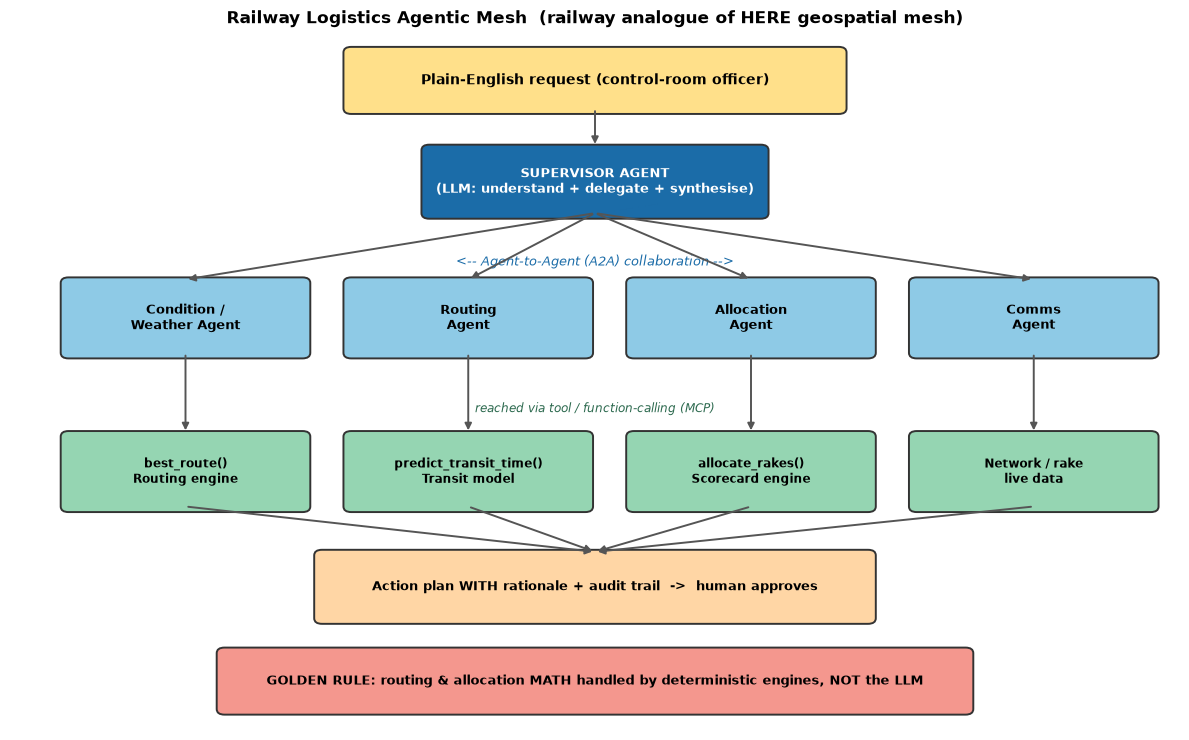

In [8]:
fig, ax = plt.subplots(figsize=(12, 7.5))
ax.axis('off'); ax.set_xlim(0, 12); ax.set_ylim(0, 10)

def box(x, y, w, h, text, fc, tc='black', fs=9, weight='normal'):
    ax.add_patch(mpatches.FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.08',
                 fc=fc, ec='#333', lw=1.4))
    ax.text(x + w/2, y + h/2, text, ha='center', va='center', fontsize=fs, color=tc,
            fontweight=weight, wrap=True)

# Layer 1: user intent
box(3.5, 8.9, 5.0, 0.8, 'Plain-English request (control-room officer)', '#ffe08a', fs=10, weight='bold')
# Layer 2: supervisor
box(4.3, 7.4, 3.4, 0.9, 'SUPERVISOR AGENT\n(LLM: understand + delegate + synthesise)', '#1b6ca8',
    tc='white', fs=9, weight='bold')
# Layer 3: agent mesh
agents = ['Condition /\nWeather Agent', 'Routing\nAgent', 'Allocation\nAgent', 'Comms\nAgent']
for i, a in enumerate(agents):
    box(0.6 + i*2.9, 5.4, 2.4, 1.0, a, '#8ecae6', fs=9, weight='bold')
ax.text(6.0, 6.65, '<-- Agent-to-Agent (A2A) collaboration -->', ha='center', fontsize=9,
        style='italic', color='#1b6ca8')
# Layer 4: deterministic engines
engines = ['best_route()\nRouting engine', 'predict_transit_time()\nTransit model',
           'allocate_rakes()\nScorecard engine', 'Network / rake\nlive data']
for i, e in enumerate(engines):
    box(0.6 + i*2.9, 3.2, 2.4, 1.0, e, '#95d5b2', fs=8.5, weight='bold')
ax.text(6.0, 4.55, 'reached via tool / function-calling (MCP)', ha='center', fontsize=8.5,
        style='italic', color='#2d6a4f')
# Layer 5: output
box(3.2, 1.6, 5.6, 0.9, 'Action plan WITH rationale + audit trail  ->  human approves', '#ffd6a5',
    fs=9.5, weight='bold')
# golden rule
box(2.2, 0.3, 7.6, 0.8, 'GOLDEN RULE: routing & allocation MATH handled by deterministic engines, '
    'NOT the LLM', '#f4978e', fs=9.5, weight='bold')

# arrows
def arrow(x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='-|>', color='#555', lw=1.4))
arrow(6.0, 8.9, 6.0, 8.35)
for i in range(4):
    arrow(6.0, 7.4, 1.8 + i*2.9, 6.45)   # supervisor -> agents
    arrow(1.8 + i*2.9, 5.4, 1.8 + i*2.9, 4.25)  # agents -> engines
    arrow(1.8 + i*2.9, 3.2, 6.0, 2.55)   # engines -> output (fan-in)
ax.set_title('Railway Logistics Agentic Mesh  (railway analogue of HERE geospatial mesh)',
             fontsize=12.5, fontweight='bold')
plt.tight_layout(); plt.show()


## 6 · Run the scenario — **"The Monsoon Washout"**

The officer types one plain-English request. The mesh decomposes it, calls the engines, and returns a
single recommended **action plan** — for the officer to approve.


In [9]:
# --- The world state at 3 a.m. ---
blocked_sections = [('Karjat', 'Lonavala')]   # 18-hour Bhor Ghat washout (as on 6 Jul 2026)

en_route_rakes = [   # 12 loaded rakes already moving that may need re-routing
    {'id': f'R{i}', 'at': at, 'dst': dst}
    for i, (at, dst) in enumerate([
        ('JNPT','Pune'), ('Kalyan','Pune'), ('Karjat','Pune'),
        ('Ahmadnagar','Pune'), ('JNPT','Solapur'), ('Karjat','Solapur'),
        ('Kalyan','Solapur'), ('Ahmadnagar','Solapur'), ('JNPT','Daund'),
        ('Karjat','Daund'), ('Kalyan','Pune'), ('Ahmadnagar','Pune'),
    ], start=1)
]

spare_rakes = {'S1': 'JNPT', 'S2': 'Ahmadnagar', 'S3': 'Kalyan'}   # 3 scarce spares

orders = [   # 4 high-value orders competing for the 3 spares
    {'id': 'O1', 'dst': 'Pune', 'tonnes': 3800, 'value': 5_200_000},
    {'id': 'O2', 'dst': 'Solapur', 'tonnes': 3200, 'value': 4_600_000},
    {'id': 'O3', 'dst': 'Daund',   'tonnes': 2600, 'value': 3_100_000},
    {'id': 'O4', 'dst': 'Pune', 'tonnes': 3000, 'value': 2_400_000},
]

world = {'G': G, 'blocked_sections': blocked_sections, 'en_route_rakes': en_route_rakes,
         'spare_rakes': spare_rakes, 'orders': orders}

query = ("Section Karjat to Pune is down for 18 hours after a washout. "
         "Re-plan my 12 rakes around it, assign the 3 spare rakes to the most valuable orders, "
         "and draft a note to any customer we deprioritise.")

print('OFFICER REQUEST:\n' + textwrap.fill(query, 96))
world = orchestrator(query, world)
print('\nDetected intents:', world['_intents'])


OFFICER REQUEST:
Section Karjat to Pune is down for 18 hours after a washout. Re-plan my 12 rakes around it,
assign the 3 spare rakes to the most valuable orders, and draft a note to any customer we
deprioritise.

Detected intents: ['handle_block', 'reroute', 'allocate', 'comms']


In [10]:
# --- The synthesised ACTION PLAN ---
print('=' * 90)
print('RECOMMENDED ACTION PLAN  (for officer approval)')
print('=' * 90)
for i, s in enumerate(world['_plan_sections'], 1):
    clean = s.replace('**', '')
    print(f'\n{i}. ' + textwrap.fill(clean, 96, subsequent_indent='   '))

print('\n' + '-' * 90)
print('RE-ROUTING DETAIL (routing engine output):')
print(world['_reroute'].to_string(index=False))

print('\n' + '-' * 90)
print('ALLOCATION DETAIL (scorecard engine output, top candidates):')
print(world['_alloc']['scorecard'].head(8)[['rake','rake_at','order','dst','value','hours','score']]
      .to_string(index=False))

print('\n' + '-' * 90)
print('DRAFT CUSTOMER NOTE (Comms agent — approve before sending):')
print(world['_comms'])


RECOMMENDED ACTION PLAN  (for officer approval)

1. Disruption: section(s) Karjat-Lonavala unavailable; re-planning around them.

2. Re-routing (12 rakes): see table below; each computed by the routing engine avoiding the outage.

3. Spare-rake allocation: S2->O1 (Pune, 4.69h), S3->O2 (Solapur, 9.35h), S1->O3 (Daund, 7.91h).
   Priority value served: Rs 12,900,000. Deprioritised: ['O4'].

4. Customer note: drafted (see below) — for officer approval before send.

------------------------------------------------------------------------------------------
RE-ROUTING DETAIL (routing engine output):
rake      to   status  hours  extra_h                                              route
  R1    Pune rerouted   7.88     3.77      JNPT -> Karjat -> Ahmadnagar -> Daund -> Pune
  R2    Pune rerouted   6.78     3.77    Kalyan -> Karjat -> Ahmadnagar -> Daund -> Pune
  R3    Pune rerouted   5.88     3.77              Karjat -> Ahmadnagar -> Daund -> Pune
  R4    Pune rerouted   3.15     0.00      

In [11]:
# --- The AUDIT TRAIL: exactly which agent did what (explainability) ---
print('AGENT TRANSCRIPT (audit trail):')
for who, what in world['_transcript']:
    print(f'  [{who:16s}] {what}')
print('\nEvery number above came from a deterministic engine — the LLM only coordinated and explained.')


AGENT TRANSCRIPT (audit trail):
  [Condition-Agent ] Confirmed outage on section Karjat <-> Lonavala.
  [Routing-Agent   ] Rake R1 JNPT->Pune: called best_route (blocked-aware).
  [Routing-Agent   ] Rake R2 Kalyan->Pune: called best_route (blocked-aware).
  [Routing-Agent   ] Rake R3 Karjat->Pune: called best_route (blocked-aware).
  [Routing-Agent   ] Rake R4 Ahmadnagar->Pune: called best_route (blocked-aware).
  [Routing-Agent   ] Rake R5 JNPT->Solapur: called best_route (blocked-aware).
  [Routing-Agent   ] Rake R6 Karjat->Solapur: called best_route (blocked-aware).
  [Routing-Agent   ] Rake R7 Kalyan->Solapur: called best_route (blocked-aware).
  [Routing-Agent   ] Rake R8 Ahmadnagar->Solapur: called best_route (blocked-aware).
  [Routing-Agent   ] Rake R9 JNPT->Daund: called best_route (blocked-aware).
  [Routing-Agent   ] Rake R10 Karjat->Daund: called best_route (blocked-aware).
  [Routing-Agent   ] Rake R11 Kalyan->Pune: called best_route (blocked-aware).
  [Routing-Agent   ] R

## 7 · What you just saw

- One **plain-English request** became a coordinated, **correct**, explainable set of actions.
- The **routing** and **allocation** numbers came from **deterministic engines** — not the LLM.
- Every recommendation carries an **audit trail** (which agent, which tool) — survives review/RTI.
- A **human approves** before anything happens — copilot, not autopilot.

This is the Session-1 map + Session-2 engines, now driven by *language*.

## 8 · Swapping our stand-in for a **real LLM** (commented — needs an API key + internet)

The only piece that changes is the *Supervisor's decision* (which tools, which order). The engines and
the safety model stay exactly the same. Below is the standard **OpenAI function-calling** shape.


In [12]:
# ---------------------------------------------------------------------------
# REAL-LLM SUPERVISOR (illustrative; requires: pip install openai + an API key)
# The deterministic engines (best_route, predict_transit_time, allocate_rakes) are UNCHANGED.
# ---------------------------------------------------------------------------
# from openai import OpenAI
# client = OpenAI()  # reads OPENAI_API_KEY from environment
#
# tools = [{
#     "type": "function",
#     "function": {
#         "name": "best_route",
#         "description": "Fastest route between two stations, avoiding blocked sections.",
#         "parameters": {"type": "object", "properties": {
#             "src": {"type": "string"}, "dst": {"type": "string"},
#             "blocked_sections": {"type": "array", "items": {"type": "array"}}},
#             "required": ["src", "dst"]},
#     }}, {
#     "type": "function",
#     "function": {
#         "name": "allocate_rakes",
#         "description": "Assign scarce spare rakes to the most valuable feasible orders.",
#         "parameters": {"type": "object", "properties": {
#             "spare_rakes": {"type": "object"}, "orders": {"type": "array"}},
#             "required": ["spare_rakes", "orders"]},
#     }},
#     # ... register predict_transit_time similarly ...
# ]
#
# def llm_supervisor(query, world):
#     messages = [
#         {"role": "system", "content": "You are a railway control-room supervisor. "
#          "NEVER compute routes or allocations yourself — ALWAYS call the provided tools. "
#          "Return a clear action plan with the reason for each action."},
#         {"role": "user", "content": query},
#     ]
#     while True:
#         resp = client.chat.completions.create(model="gpt-4o", messages=messages, tools=tools)
#         msg = resp.choices[0].message
#         if not msg.tool_calls:
#             return msg.content                      # final synthesised action plan
#         for call in msg.tool_calls:                 # LLM chose which engine(s) to run
#             fn = TOOL_REGISTRY[call.function.name]['fn']
#             args = json.loads(call.function.arguments)
#             result = fn(world['G'], **args)         # DETERMINISTIC engine does the maths
#             messages.append({"role": "tool", "tool_call_id": call.id,
#                              "content": json.dumps(result, default=str)})
#
# NOTE: the loop above IS the plan-act-observe agent loop from the slides.
print('Real-LLM wiring shown above as commented code. The offline demo needs none of it.')


Real-LLM wiring shown above as commented code. The offline demo needs none of it.


## 9 · Talking points & honest limits (for the room)

**Why this is the right design**
- **Correctness:** deterministic engines → exact, repeatable routing/allocation numbers.
- **Explainability:** every action has an audit trail (agent + tool + inputs).
- **Control:** human approves before action — decision *support*, not replacement.

**Honest limits**
- LLMs cost money and can **hallucinate** — so keep the maths in engines and a human in the loop.
- **Data privacy/residency:** decide what may leave your network; on-prem/open models are an option.
- Start as a **copilot for one control room on one corridor**, human-approved, before anything more.

**One-line close for the day:**
> *Session 1 made the railway a map. Session 2 turned the map into decisions. This module showed how
> tomorrow's interface to all of it can simply be plain language — over engines you can trust.*
